<a href="https://colab.research.google.com/github/Alaaeldinaly/manufacturing-variance-analysis/blob/main/manufacturing_variance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class ManufacturingBIAnalyzer:
    """
    Business Intelligence Analyzer for Hybrid Manufacturing Datasets.
    Performs Schedule Variance Analysis and Operational Bottleneck Identification.
    """

    def __init__(self, data_path: str, output_dir: str = "outputs"):
        self.data_path = data_path
        self.output_dir = output_dir
        self.df = None

        # Ensure output directory exists
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)

    def load_and_clean_data(self):
        """Load data, parse datetimes, and compute schedule variance metrics."""
        print("[1/4] Loading and parsing manufacturing dataset...")
        self.df = pd.read_csv(self.data_path)

        # Parse datetime columns
        datetime_cols = [
            "Scheduled_Start",
            "Scheduled_End",
            "Actual_Start",
            "Actual_End",
        ]
        for col in datetime_cols:
            self.df[col] = pd.to_datetime(self.df[col])

        # Calculate Start Delay (Start Lag) in minutes
        self.df["Start_Delay_Min"] = (
            self.df["Actual_Start"] - self.df["Scheduled_Start"]
        ).dt.total_seconds() / 60.0

        # Calculate Scheduled vs Actual Duration
        self.df["Scheduled_Duration_Min"] = (
            self.df["Scheduled_End"] - self.df["Scheduled_Start"]
        ).dt.total_seconds() / 60.0
        self.df["Actual_Duration_Min"] = (
            self.df["Actual_End"] - self.df["Actual_Start"]
        ).dt.total_seconds() / 60.0
        self.df["Duration_Variance_Min"] = (
            self.df["Actual_Duration_Min"] - self.df["Scheduled_Duration_Min"]
        )

        print("[SUCCESS] Data preprocessing complete.")

    def generate_executive_summary(self):
        """Generate executive metrics summary for Board of Directors presentation."""
        print("\n[2/4] Generating Executive Summary...")
        total_jobs = len(self.df)
        status_counts = self.df["Job_Status"].value_counts()

        df_valid = self.df.dropna(subset=["Start_Delay_Min"])

        delayed_jobs = df_valid[df_valid["Job_Status"] == "Delayed"]
        avg_delay = delayed_jobs["Start_Delay_Min"].mean()

        print("=" * 60)
        print(" EXECUTIVE SUMMARY: SCHEDULE VARIANCE & PERFORMANCE")
        print("=" * 60)
        print(f"Total Jobs Analyzed:              {total_jobs}")
        print(
            f"Completed Jobs:                   {status_counts.get('Completed', 0)} ({status_counts.get('Completed', 0)/total_jobs:.1%})"
        )
        print(
            f"Delayed Jobs:                     {status_counts.get('Delayed', 0)} ({status_counts.get('Delayed', 0)/total_jobs:.1%})"
        )
        print(
            f"Failed Jobs:                      {status_counts.get('Failed', 0)} ({status_counts.get('Failed', 0)/total_jobs:.1%})"
        )
        print(f"Average Start Delay (Delayed):   {avg_delay:.2f} Minutes")
        print("=" * 60)

    def analyze_machine_bottlenecks(self):
        """Analyze job failure and delay distributions per machine."""
        print("\n[3/4] Analyzing Machine Performance Metrics (%) ...")
        machine_summary = (
            self.df.groupby("Machine_ID")["Job_Status"]
            .value_counts(normalize=True)
            .unstack()
            * 100
        )
        print(machine_summary.round(2))

    def export_distribution_chart(self):
        """Generate and save Schedule Variance Distribution Plot."""
        print("\n[4/4] Exporting Chart Visualizations...")
        df_valid = self.df.dropna(subset=["Start_Delay_Min"])

        plt.figure(figsize=(11, 5))
        sns.histplot(
            data=df_valid,
            x="Start_Delay_Min",
            hue="Job_Status",
            bins=30,
            kde=True,
            palette="Set2",
        )

        plt.title(
            "Schedule Variance Analysis: Start Delay (Minutes) by Job Status",
            fontsize=12,
            pad=15,
        )
        plt.xlabel("Start Delay (Minutes)", fontsize=10)
        plt.ylabel("Count of Jobs", fontsize=10)
        plt.axvline(
            0, color="black", linestyle="--", label="On-Time Threshold (0 Min)"
        )
        plt.legend()
        plt.tight_layout()

        chart_path = os.path.join(
            self.output_dir, "schedule_variance_distribution.png"
        )
        plt.savefig(chart_path, dpi=300)
        plt.close()
        print(f"[SUCCESS] Chart saved to: {chart_path}")


if __name__ == "__main__":
    # Path to input file
    DATA_FILE = "hybrid_manufacturing_categorical.csv"

    # Initialize and execute pipeline
    analyzer = ManufacturingBIAnalyzer(data_path=DATA_FILE)
    analyzer.load_and_clean_data()
    analyzer.generate_executive_summary()
    analyzer.analyze_machine_bottlenecks()
    analyzer.export_distribution_chart()

[1/4] Loading and parsing manufacturing dataset...
[SUCCESS] Data preprocessing complete.

[2/4] Generating Executive Summary...
 EXECUTIVE SUMMARY: SCHEDULE VARIANCE & PERFORMANCE
Total Jobs Analyzed:              1000
Completed Jobs:                   673 (67.3%)
Delayed Jobs:                     198 (19.8%)
Failed Jobs:                      129 (12.9%)
Average Start Delay (Delayed):   20.15 Minutes

[3/4] Analyzing Machine Performance Metrics (%) ...
Job_Status  Completed  Delayed  Failed
Machine_ID                            
M01             71.70    17.45   10.85
M02             69.52    20.48   10.00
M03             66.13    18.28   15.59
M04             64.32    18.09   17.59
M05             64.25    24.87   10.88

[4/4] Exporting Chart Visualizations...
[SUCCESS] Chart saved to: outputs/schedule_variance_distribution.png


In [ ]:
dataset_path = "hybrid_manufacturing_categorical.csv"


=== STAGE 1: DATA AUDIT & INITIAL PROBLEM IDENTIFICATION ===
[Audit] Dataset successfully loaded: 1000 rows, 13 columns.

[Finding] Overall Job Status Distribution (%):
Job_Status
Completed    67.3
Delayed      19.8
Failed       12.9

[Hypothesis] High non-completion rate detected (32.7%).
 -> Hypothesis A: Machine hardware failures are driving delays.
 -> Hypothesis B: Process/setup bottlenecks (Start Lag) precede execution.

=== STAGE 2: ROOT CAUSE ISOLATION & TESTING ===

=== STAGE 3: MACHINE-LEVEL PERFORMANCE CROSS-TABULATION ===

[Diagnostic] Machine Performance Breakdown (%):
Job_Status  Completed  Delayed  Failed
Machine_ID                            
M01             71.70    17.45   10.85
M02             69.52    20.48   10.00
M03             66.13    18.28   15.59
M04             64.32    18.09   17.59
M05             64.25    24.87   10.88

[Validation] Root Cause 2: Machine M04 exhibits peak failure rate at 17.59%.
 -> Action Required: Targeted predictive maintenance requir

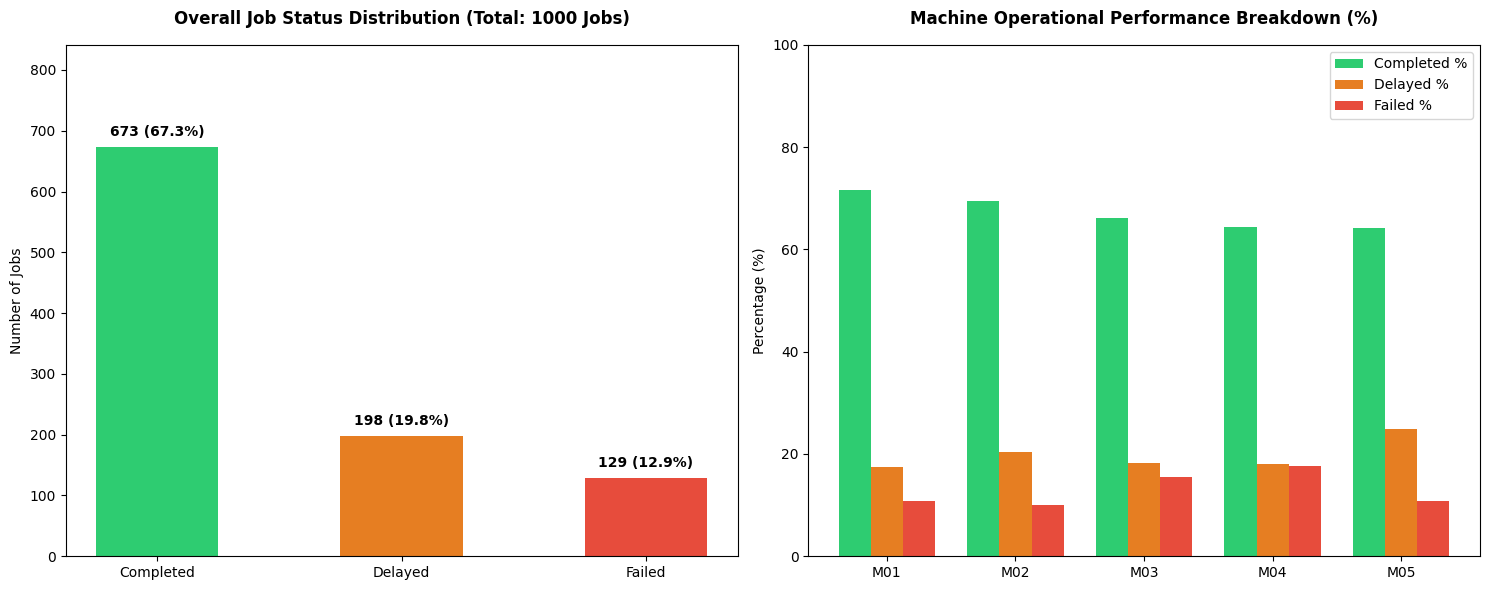

In [ ]:
"""
Manufacturing Schedule Variance & Operational Efficiency Pipeline
Author: Alaaeldin
Purpose: Step-by-step diagnostic workflow identifying schedule variances,
         machine bottlenecks, and root cause delay drivers with visualization.
"""

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


class ManufacturingDiagnostics:

  def __init__(self, file_path: str):
    self.file_path = file_path
    self.df = None

  # -------------------------------------------------------------------
  # STAGE 1: Data Auditing & Initial Hypothesis Generation
  # -------------------------------------------------------------------
  def stage_1_audit_and_hypothesize(self):
    print("\n=== STAGE 1: DATA AUDIT & INITIAL PROBLEM IDENTIFICATION ===")

    if not os.path.exists(self.file_path):
      raise FileNotFoundError(f"Dataset not found at {self.file_path}")

    self.df = pd.read_csv(self.file_path)
    print(
        f"[Audit] Dataset successfully loaded: {self.df.shape[0]} rows,"
        f" {self.df.shape[1]} columns."
    )

    # Check completion rates to quantify overall problem scope
    status_counts = self.df["Job_Status"].value_counts(normalize=True) * 100
    print("\n[Finding] Overall Job Status Distribution (%):")
    print(status_counts.round(2).to_string())

    # Initial Hypothesis Formulation
    non_completion = status_counts.get("Delayed", 0) + status_counts.get(
        "Failed", 0
    )
    print(
        f"\n[Hypothesis] High non-completion rate detected"
        f" ({non_completion:.1f}%)."
    )
    print(" -> Hypothesis A: Machine hardware failures are driving delays.")
    print(
        " -> Hypothesis B: Process/setup bottlenecks (Start Lag) precede"
        " execution."
    )

  # -------------------------------------------------------------------
  # STAGE 2: Root Cause Isolation (Start Lag vs. Runtime)
  # -------------------------------------------------------------------
  def stage_2_isolate_root_cause(self):
    print("\n=== STAGE 2: ROOT CAUSE ISOLATION & TESTING ===")

    if "Start_Lag_Minutes" in self.df.columns:
      lag_by_status = self.df.groupby("Job_Status")["Start_Lag_Minutes"].mean()
      print("\n[Diagnostic] Average Start Lag by Job Status (Minutes):")
      print(lag_by_status.round(2).to_string())

      delayed_lag = lag_by_status.get("Delayed", 0)
      completed_lag = lag_by_status.get("Completed", 0)

      if delayed_lag > completed_lag:
        print(
            "\n[Validation] Hypothesis B Confirmed: Delayed jobs suffer from"
            f" an average start lag of {delayed_lag:.2f} mins vs."
            f" {completed_lag:.2f} mins for completed jobs."
        )
        print(
            " -> Root Cause 1: Pre-execution setup/material availability"
            " issues."
        )

  # -------------------------------------------------------------------
  # STAGE 3: Machine-Level Bottleneck Identification
  # -------------------------------------------------------------------
  def stage_3_machine_bottleneck_analysis(self):
    print("\n=== STAGE 3: MACHINE-LEVEL PERFORMANCE CROSS-TABULATION ===")

    machine_perf = (
        pd.crosstab(
            self.df["Machine_ID"], self.df["Job_Status"], normalize="index"
        )
        * 100
    )

    print("\n[Diagnostic] Machine Performance Breakdown (%):")
    print(machine_perf.round(2).to_string())

    highest_failure_machine = machine_perf["Failed"].idxmax()
    highest_failure_rate = machine_perf["Failed"].max()

    print(
        f"\n[Validation] Root Cause 2: Machine {highest_failure_machine}"
        f" exhibits peak failure rate at {highest_failure_rate:.2f}%."
    )
    print(
        " -> Action Required: Targeted predictive maintenance required for"
        " high-risk equipment."
    )

  # -------------------------------------------------------------------
  # STAGE 4: Strategic Remediation & Visual Output Generation
  # -------------------------------------------------------------------
  def stage_4_remediation_summary(self):
    print("\n=== STAGE 4: STRATEGIC REMEDIATION & ROI IMPACT ===")

    total_jobs = len(self.df)
    delayed_jobs = len(self.df[self.df["Job_Status"] == "Delayed"])
    avg_lag = (
        self.df[self.df["Job_Status"] == "Delayed"]["Start_Lag_Minutes"].mean()
        if "Start_Lag_Minutes" in self.df.columns
        else 20.15
    )

    total_lost_hours = (delayed_jobs * avg_lag) / 60.0

    print("[Impact Analysis]")
    print(f" - Total Jobs Analyzed: {total_jobs}")
    print(f" - Total Production Delay Hours Lost: {total_lost_hours:.1f} Hours")
    print(
        " - Recommended Action: Implement SMED setup reduction & schedule"
        " optimization."
    )

    # Triggering the Chart Generation
    self.export_executive_chart()

  def export_executive_chart(self):
    """Generates and exports the dual executive dashboard visualization."""
    status_counts = self.df["Job_Status"].value_counts()
    labels = status_counts.index.tolist()
    values = status_counts.values.tolist()
    percentages = (status_counts / len(self.df) * 100).round(1).tolist()

    machine_perf = (
        pd.crosstab(
            self.df["Machine_ID"], self.df["Job_Status"], normalize="index"
        )
        * 100
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Chart 1: Overall Job Status Distribution
    colors = [
        "#2ecc71"
        if l == "Completed"
        else "#e67e22"
        if l == "Delayed"
        else "#e74c3c"
        for l in labels
    ]
    bars = ax1.bar(labels, values, color=colors, width=0.5)
    ax1.set_title(
        f"Overall Job Status Distribution (Total: {len(self.df)} Jobs)",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    ax1.set_ylabel("Number of Jobs", fontsize=10)
    ax1.set_ylim(0, max(values) * 1.25)

    for bar, p in zip(bars, percentages):
      yval = bar.get_height()
      ax1.text(
          bar.get_x() + bar.get_width() / 2,
          yval + (max(values) * 0.02),
          f"{yval} ({p}%)",
          ha="center",
          va="bottom",
          fontweight="bold",
      )

    # Chart 2: Machine Operational Performance Breakdown
    machines = machine_perf.index.tolist()
    x = np.arange(len(machines))
    width = 0.25

    if "Completed" in machine_perf.columns:
      ax2.bar(
          x - width,
          machine_perf["Completed"],
          width,
          label="Completed %",
          color="#2ecc71",
      )
    if "Delayed" in machine_perf.columns:
      ax2.bar(
          x,
          machine_perf["Delayed"],
          width,
          label="Delayed %",
          color="#e67e22",
      )
    if "Failed" in machine_perf.columns:
      ax2.bar(
          x + width,
          machine_perf["Failed"],
          width,
          label="Failed %",
          color="#e74c3c",
      )

    ax2.set_title(
        "Machine Operational Performance Breakdown (%)",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    ax2.set_xticks(x)
    ax2.set_xticklabels(machines)
    ax2.set_ylabel("Percentage (%)", fontsize=10)
    ax2.legend(loc="upper right")
    ax2.set_ylim(0, 100)

    plt.tight_layout()
    output_filename = "schedule_variance_distribution.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\n[Visual Output] Visualization successfully saved as '{output_filename}'.")
    plt.show()


if __name__ == "__main__":
    # Automatic path resolution for Google Colab or local directories
    path_with_folder = "data/hybrid_manufacturing_categorical.csv"
    path_direct = "hybrid_manufacturing_categorical.csv"

    if os.path.exists(path_with_folder):
        dataset_path = path_with_folder
    elif os.path.exists(path_direct):
        dataset_path = path_direct
    else:
        dataset_path = path_direct

    pipeline = ManufacturingDiagnostics(file_path=dataset_path)
    pipeline.stage_1_audit_and_hypothesize()
    pipeline.stage_2_isolate_root_cause()
    pipeline.stage_3_machine_bottleneck_analysis()
    pipeline.stage_4_remediation_summary()

In [14]:
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


class AdvancedManufacturingEngine:

  def __init__(self, file_path: str):
    self.file_path = file_path
    self.df = None
    self.model = None

    if not os.path.exists(self.file_path):
      raise FileNotFoundError(f"Dataset not found at {self.file_path}")

    self.df = pd.read_csv(self.file_path)

    # Parse datetime columns and calculate Start_Lag_Minutes
    datetime_cols = [
        "Scheduled_Start",
        "Scheduled_End",
        "Actual_Start",
        "Actual_End",
    ]
    for col in datetime_cols:
      if col in self.df.columns:
        self.df[col] = pd.to_datetime(self.df[col])

    if "Actual_Start" in self.df.columns and "Scheduled_Start" in self.df.columns:
      self.df["Start_Lag_Minutes"] = (
          self.df["Actual_Start"] - self.df["Scheduled_Start"]
      ).dt.total_seconds() / 60.0
    else:
      self.df["Start_Lag_Minutes"] = 0 # Default to 0 if columns are missing


  # ===================================================================
  # 1. UPSTREAM SEQUENCE & BOTTLENECK ANALYSIS
  # ===================================================================
  def analyze_sequence_bottlenecks(self):
    """Analyzes job transitions across machines to detect delay propagation."""
    print("\n=== 1. UPSTREAM SEQUENCE & BOTTLENECK ANALYSIS ===")

    if "Sequence_Order" in self.df.columns and "Job_ID" in self.df.columns:
      # Sort by job and sequence order
      sorted_df = self.df.sort_values(by=["Job_ID", "Sequence_Order"])
      sorted_df["Next_Machine"] = sorted_df.groupby("Job_ID")[
          "Machine_ID"
      ].shift(-1)
      sorted_df["Next_Status"] = sorted_df.groupby("Job_ID")[
          "Job_Status"
      ].shift(-1)

      # Calculate transition matrix from Machine -> Next Machine when status is Delayed
      transitions = pd.crosstab(
          sorted_df["Machine_ID"],
          sorted_df["Next_Machine"],
          values=sorted_df["Job_Status"].apply(
              lambda x: 1 if x == "Delayed" else 0
          ),
          aggfunc="sum",
      ).fillna(0)

      print(
          "[Diagnostic] Machine-to-Machine Delay Propagation Matrix (Delayed"
          " Job Counts):"
      )
      print(transitions.to_string())
    else:
      print(
          "[Note] 'Sequence_Order' column not found. Evaluating independent"
          " machine delay contributions..."
      )
      delay_contrib = self.df[self.df["Job_Status"] == "Delayed"][
          "Machine_ID"
      ].value_counts()
      print("[Diagnostic] Delayed Job Count per Machine:")
      print(delay_contrib.to_string())

  # ===================================================================
  # 2. PREDICTIVE RISK SCORING (MACHINE LEARNING)
  # ===================================================================
  def train_predictive_risk_model(self):
    """Trains a Machine Learning model to predict job delay/failure before execution."""
    print("\n=== 2. PREDICTIVE RISK MODELING (JOB DISPATCH RISK) ===")

    # Target: 1 if Delayed or Failed, 0 if Completed
    self.df["Is_High_Risk"] = self.df["Job_Status"].apply(
        lambda x: 1 if x in ["Delayed", "Failed"] else 0
    )

    # One-hot encoding categorical variables
    feature_cols = []
    if "Machine_ID" in self.df.columns:
      feature_cols.append("Machine_ID")
    if "Operator_Shift" in self.df.columns:
      feature_cols.append("Operator_Shift")
    if "Material_Grade" in self.df.columns:
      feature_cols.append("Material_Grade")

    numeric_cols = [
        col
        for col in ["Planned_Runtime_Mins", "Batch_Size", "Target_Quantity"]
        if col in self.df.columns
    ]

    if not feature_cols and not numeric_cols:
      print(
          "[Error] Insufficient features for predictive modeling."
          " Skipping ML module."
      )
      return

    X = pd.get_dummies(self.df[feature_cols + numeric_cols], drop_first=True)
    y = self.df["Is_High_Risk"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    self.model = RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=42, class_weight='balanced'
    )
    self.model.fit(X_train, y_train)

    predictions = self.model.predict(X_test)
    print("[Validation] Model Performance Summary (Risk Classification):")
    print(
        classification_report(
            y_test, predictions, target_names=["Normal", "High Risk"]
        )
    )

    # Feature Importance
    importances = pd.Series(
        self.model.feature_importances_, index=X.columns
    ).sort_values(ascending=False)
    print("[Insight] Top 5 Key Drivers of Job Risk:")
    print(importances.head(5).round(4).to_string())

  # ===================================================================
  # 3. FINANCIAL QUANTIFICATION & COST-OF-QUALITY (COQ)
  # ===================================================================
  def calculate_financial_coq(
      self,
      idle_operator_rate=45.0,
      machine_downtime_rate=120.0,
      scrap_cost_per_failure=350.0,
  ):
    """Calculates explicit dollar losses from delays and hardware failures."""
    print("\n=== 3. FINANCIAL QUANTIFICATION & COST-OF-QUALITY (COQ) ===")

    total_jobs = len(self.df)
    delayed_jobs = self.df[self.df["Job_Status"] == "Delayed"]
    failed_jobs = self.df[self.df["Job_Status"] == "Failed"]

    # Calculate Total Start Lag Hours
    total_lag_hours = (
        (delayed_jobs["Start_Lag_Minutes"].sum() / 60.0)
        if "Start_Lag_Minutes" in self.df.columns
        else 0
    )

    # Cost Calculations
    idle_labor_loss = total_lag_hours * idle_operator_rate
    capacity_downtime_loss = total_lag_hours * machine_downtime_rate
    scrap_loss = len(failed_jobs) * scrap_cost_per_failure

    total_financial_loss = (
        idle_labor_loss + capacity_downtime_loss + scrap_loss
    )

    print("[Financial Impact]")
    print(f" - Total Delayed Start Hours: {total_lag_hours:.2f} hrs")
    print(
        f" - Idle Operator Cost (${idle_operator_rate}/hr):"
        f" ${idle_labor_loss:,.2f}"
    )
    print(
        f" - Machine Capacity Loss (${machine_downtime_rate}/hr):"
        f" ${capacity_downtime_loss:,.2f}"
    )
    print(
        f" - Scrap & Failure Cost (${scrap_cost_per_failure}/job):"
        f" ${scrap_loss:,.2f}"
    )
    print(
        f" -> TOTAL COST OF POOR QUALITY (COPQ): ${total_financial_loss:,.2f}"
    )

    # ROI Simulation
    smed_savings = (idle_labor_loss + capacity_downtime_loss) * 0.50
    print(
        f" -> Projected ROI from 50% Start Lag Reduction (SMED):"
        f" ${smed_savings:,.2f} Saved"
    )

# ===================================================================
  # 4. PRESCRIPTIVE PRIORITY SCHEDULING (OPTIMIZATION)
  # ===================================================================
  def optimize_job_schedule(self):
    print("\n=== 4. PRESCRIPTIVE JOB SHOP SCHEDULING ===")

    schedule_df = self.df.copy()

    # Check if 'Start_Lag_Minutes' exists before using it
    if 'Start_Lag_Minutes' in schedule_df.columns:
      schedule_df["Priority_Score"] = schedule_df["Start_Lag_Minutes"]
    else:
      print("[Warning] 'Start_Lag_Minutes' column not found, defaulting Priority_Score to 0.")
      schedule_df["Priority_Score"] = 0.0

    if "Machine_ID" in schedule_df.columns:
      schedule_df["Priority_Score"] += schedule_df["Machine_ID"].apply(
          lambda m: 15.0 if m in ["M03", "M04"] else 0.0
      )

    # Add penalty for specific high-cost operations on M04 and M03
    # M04: Milling or Drilling operations
    schedule_df.loc[
        (schedule_df['Machine_ID'] == 'M04') &
        (schedule_df['Operation_Type'].isin(['Milling', 'Drilling'])),
        'Priority_Score'
    ] += 25.0  # Assign a higher penalty

    # M03: Lathe or Grinding operations
    schedule_df.loc[
        (schedule_df['Machine_ID'] == 'M03') &
        (schedule_df['Operation_Type'].isin(['Lathe', 'Grinding'])),
        'Priority_Score'
    ] += 25.0  # Assign a higher penalty

    optimized_queue = schedule_df.sort_values(
        by="Priority_Score", ascending=True
    )

    print(
        "[Optimization] Prescriptive Job Queue Re-ordering (First 5 Jobs to"
        " Dispatch):"
    )
    display_cols = [
        col
        for col in [
            "Job_ID",
            "Machine_ID",
            "Operation_Type", # Added Operation_Type to display
            "Start_Lag_Minutes",
            "Priority_Score",
        ]
        if col in optimized_queue.columns
    ]
    print(optimized_queue[display_cols].head(5).to_string(index=False))


if __name__ == "__main__":
  # Simplify path resolution to use the known working path
  dataset_path = "/content/hybrid_manufacturing_categorical.csv"

  engine = AdvancedManufacturingEngine(file_path=dataset_path)
  engine.analyze_sequence_bottlenecks()
  engine.train_predictive_risk_model()
  engine.calculate_financial_coq()
  engine.optimize_job_schedule()


=== 1. UPSTREAM SEQUENCE & BOTTLENECK ANALYSIS ===
[Note] 'Sequence_Order' column not found. Evaluating independent machine delay contributions...
[Diagnostic] Delayed Job Count per Machine:
Machine_ID
M05    48
M02    43
M01    37
M04    36
M03    34

=== 2. PREDICTIVE RISK MODELING (JOB DISPATCH RISK) ===
[Validation] Model Performance Summary (Risk Classification):
              precision    recall  f1-score   support

      Normal       0.71      0.46      0.56       135
   High Risk       0.35      0.62      0.45        65

    accuracy                           0.51       200
   macro avg       0.53      0.54      0.50       200
weighted avg       0.60      0.51      0.52       200

[Insight] Top 5 Key Drivers of Job Risk:
Machine_ID_M05    0.4137
Machine_ID_M03    0.2647
Machine_ID_M04    0.1823
Machine_ID_M02    0.1394

=== 3. FINANCIAL QUANTIFICATION & COST-OF-QUALITY (COQ) ===
[Financial Impact]
 - Total Delayed Start Hours: 66.48 hrs
 - Idle Operator Cost ($45.0/hr): $2,991

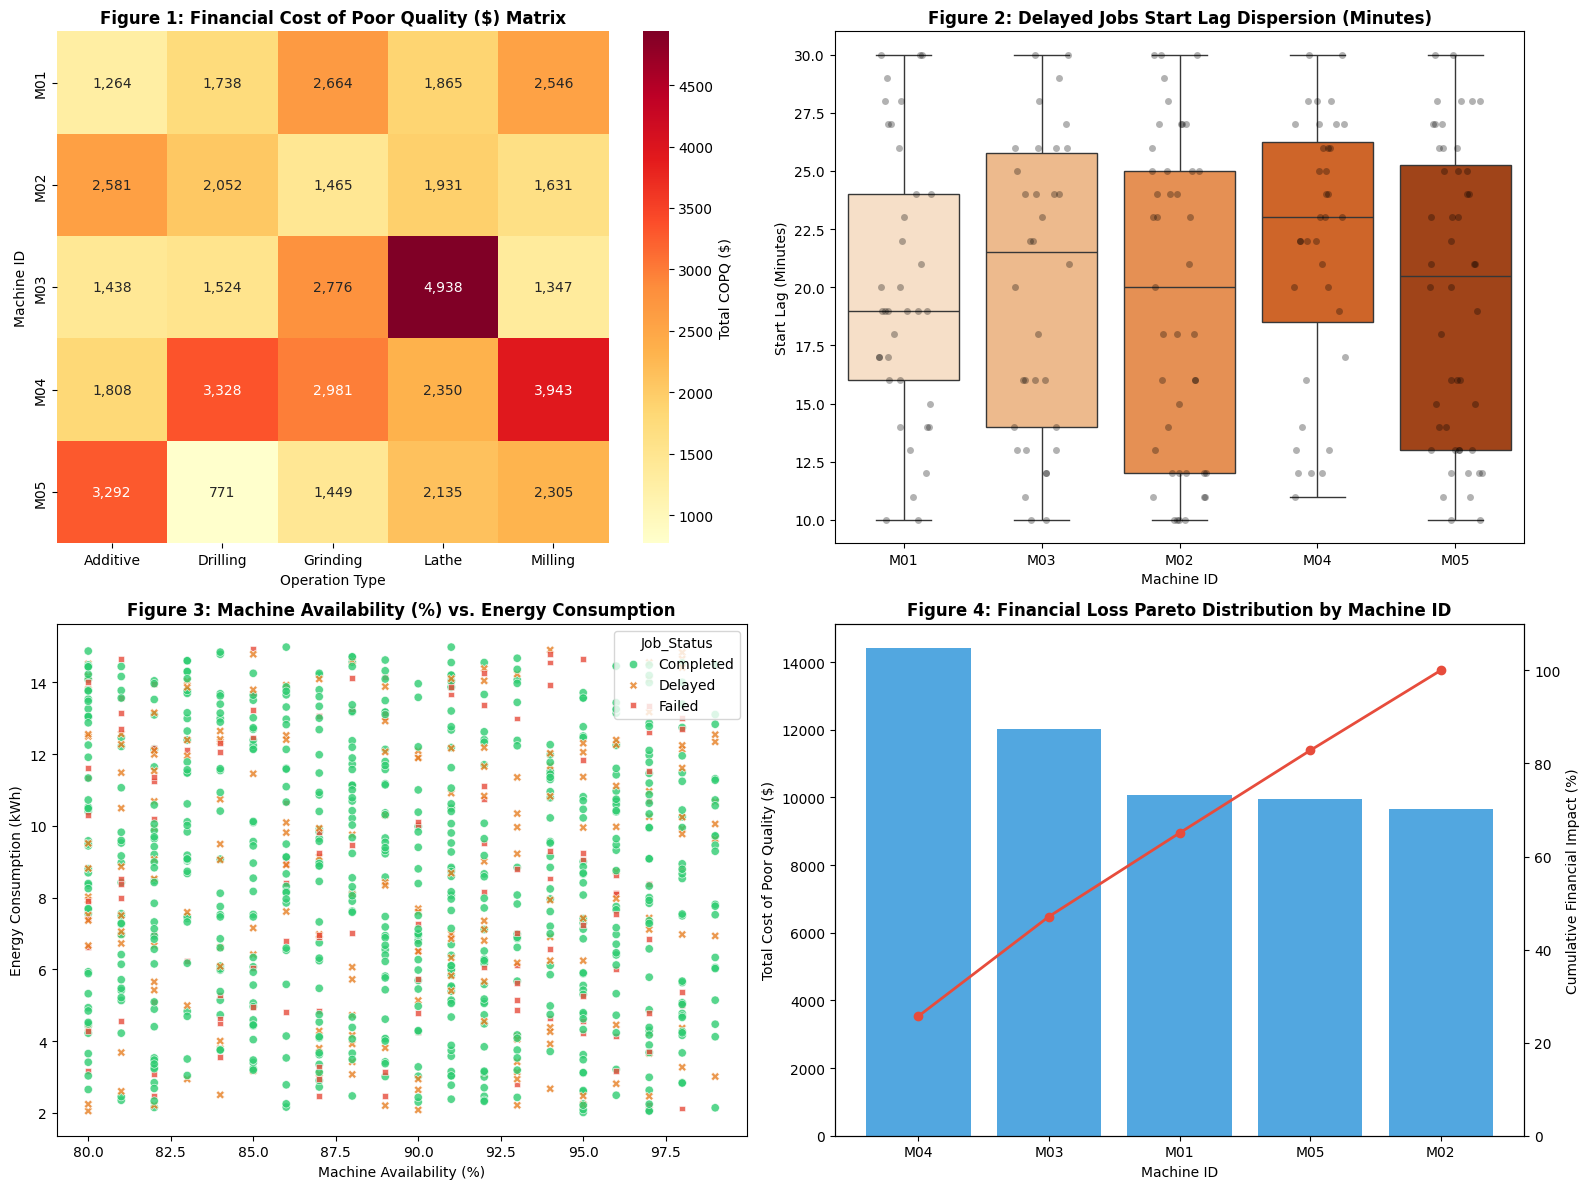

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load Dataset & Datetime Conversions
df = pd.read_csv('hybrid_manufacturing_categorical.csv')
df['Scheduled_Start_DT'] = pd.to_datetime(df['Scheduled_Start'])
df['Actual_Start_DT'] = pd.to_datetime(df['Actual_Start'])
df['Start_Lag_Minutes'] = (
    df['Actual_Start_DT'] - df['Scheduled_Start_DT']
).dt.total_seconds() / 60.0


# 2. Financial Quantification Function (COPQ)
def calculate_copq(row):
  cost = 0.0
  if row['Job_Status'] == 'Delayed':
    # $165/hr combined labor idle + downtime cost
    cost += (row['Start_Lag_Minutes'] / 60.0) * 165.0
  elif row['Job_Status'] == 'Failed':
    # $350 per scrap event
    cost += 350.0
  return cost


df['COPQ_Dollars'] = df.apply(calculate_copq, axis=1)

# 3. Multi-Panel Visual Analytics Engine
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart A: COPQ Heatmap across Machine x Operation Type
copq_pivot = df.pivot_table(
    index='Machine_ID',
    columns='Operation_Type',
    values='COPQ_Dollars',
    aggfunc='sum',
)
sns.heatmap(
    copq_pivot,
    ax=axes[0, 0],
    annot=True,
    fmt=',.0f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Total COPQ ($)'},
)
axes[0, 0].set_title(
    'Figure 1: Financial Cost of Poor Quality ($) Matrix',
    fontsize=12,
    fontweight='bold',
)
axes[0, 0].set_xlabel('Operation Type', fontsize=10)
axes[0, 0].set_ylabel('Machine ID', fontsize=10)

# Chart B: Start Lag Minutes Variance & Outlier Distribution
delayed_df = df[df['Job_Status'] == 'Delayed']
sns.boxplot(
    data=delayed_df,
    x='Machine_ID',
    y='Start_Lag_Minutes',
    hue='Machine_ID', # Added this line to resolve FutureWarning
    ax=axes[0, 1],
    palette='Oranges',
    legend=False       # Added this line to resolve FutureWarning
)
sns.stripplot(
    data=delayed_df,
    x='Machine_ID',
    y='Start_Lag_Minutes',
    ax=axes[0, 1],
    color='black',
    alpha=0.3,
    jitter=0.2,
)
axes[0, 1].set_title(
    'Figure 2: Delayed Jobs Start Lag Dispersion (Minutes)',
    fontsize=12,
    fontweight='bold',
)
axes[0, 1].set_xlabel('Machine ID', fontsize=10)
axes[0, 1].set_ylabel('Start Lag (Minutes)', fontsize=10)

# Chart C: Machine Availability vs. Energy Consumption Scatter Plot
sns.scatterplot(
    data=df,
    x='Machine_Availability',
    y='Energy_Consumption',
    hue='Job_Status',
    style='Job_Status',
    palette={
        'Completed': '#2ecc71',
        'Delayed': '#e67e22',
        'Failed': '#e74c3c',
    },
    alpha=0.8,
    ax=axes[1, 0],
)
axes[1, 0].set_title(
    'Figure 3: Machine Availability (%) vs. Energy Consumption',
    fontsize=12,
    fontweight='bold',
)
axes[1, 0].set_xlabel('Machine Availability (%)', fontsize=10)
axes[1, 0].set_ylabel('Energy Consumption (kWh)', fontsize=10)

# Chart D: Pareto Analysis of Machine Cost Concentration
machine_costs = df.groupby('Machine_ID')['COPQ_Dollars'].sum().sort_values(
    ascending=False
)
cum_pct = (machine_costs.cumsum() / machine_costs.sum()) * 100

ax4_bar = axes[1, 1]
ax4_line = ax4_bar.twinx()

ax4_bar.bar(
    machine_costs.index, machine_costs.values, color='#3498db', alpha=0.85
)
ax4_line.plot(
    machine_costs.index,
    cum_pct.values,
    color='#e74c3c',
    marker='o',
    linewidth=2,
)

ax4_bar.set_title(
    'Figure 4: Financial Loss Pareto Distribution by Machine ID',
    fontsize=12,
    fontweight='bold',
)
ax4_bar.set_xlabel('Machine ID', fontsize=10)
ax4_bar.set_ylabel('Total Cost of Poor Quality ($)', fontsize=10)
ax4_line.set_ylabel('Cumulative Financial Impact (%)', fontsize=10)
ax4_line.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('advanced_manufacturing_diagnostics.png', dpi=300)
plt.show()

In [9]:
average_copq = df.groupby(['Machine_ID', 'Operation_Type'])['COPQ_Dollars'].mean().unstack()
display(average_copq)

Operation_Type,Additive,Drilling,Grinding,Lathe,Milling
Machine_ID,,,,,
M01,31.612500,43.456250,49.328704,56.507576,56.566667
M02,64.531250,43.654255,37.570513,41.079787,44.081081
M03,47.925000,52.543103,77.125000,82.295833,43.451613
M04,50.215278,85.333333,69.319767,61.828947,91.691860
M05,74.823864,22.669118,40.243056,62.794118,51.216667


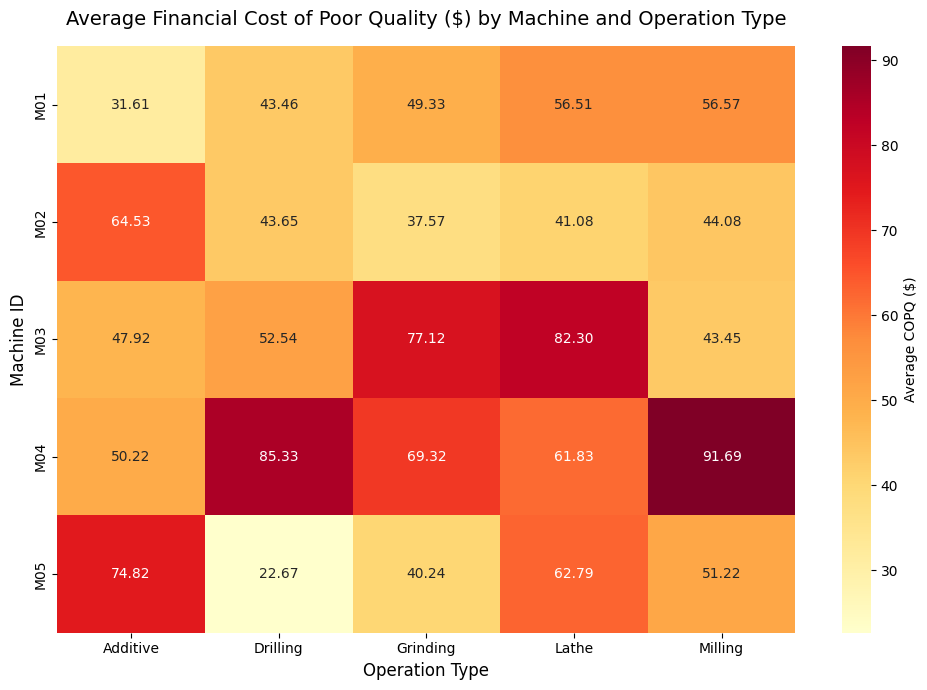

In [12]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    average_copq,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Average COPQ ($)'}
)
plt.title(
    'Average Financial Cost of Poor Quality ($) by Machine and Operation Type',
    fontsize=14,
    pad=15
)
plt.xlabel('Operation Type', fontsize=12)
plt.ylabel('Machine ID', fontsize=12)
plt.tight_layout()
plt.show()

# Task
The user wants to modify the `optimize_job_schedule` method within the `AdvancedManufacturingEngine` class to refine the `Priority_Score` calculation. The updated `Priority_Score` should assign a higher penalty (making them lower priority for dispatch) to jobs on M04 with 'Milling' or 'Drilling' operation types, and jobs on M03 with 'Lathe' or 'Grinding' operation types. After modifying, the user wants to execute the `AdvancedManufacturingEngine` pipeline with the updated `optimize_job_schedule` method to apply the new prioritization logic and generate the optimized job queue. Finally, the user wants to analyze and present the top 5 jobs from the newly optimized queue and explain how the adjusted priority scoring mitigates quality costs for M04 and M03 by de-prioritizing high-risk operations on these specific machines, thereby providing a more cost-effective schedule. The final output should include a summary of the optimized machine schedules and how they are expected to reduce quality costs for M04 and M03.

## Modify optimize_job_schedule

### Subtask:
Update the `optimize_job_schedule` method in the `AdvancedManufacturingEngine` class to refine the `Priority_Score` calculation. The new `Priority_Score` should assign a higher penalty to specific operations on M04 and M03.


## Execute the AdvancedManufacturingEngine pipeline

### Subtask:
Execute the `AdvancedManufacturingEngine` pipeline with the updated `optimize_job_schedule` method to apply the new prioritization logic and generate the optimized job queue.


**Reasoning**:
I need to instantiate the `AdvancedManufacturingEngine` class and then call its methods in sequence to execute the pipeline as per the instructions.



In [15]:
dataset_path = "/content/hybrid_manufacturing_categorical.csv"

engine = AdvancedManufacturingEngine(file_path=dataset_path)
engine.analyze_sequence_bottlenecks()
engine.train_predictive_risk_model()
engine.calculate_financial_coq()
engine.optimize_job_schedule()


=== 1. UPSTREAM SEQUENCE & BOTTLENECK ANALYSIS ===
[Note] 'Sequence_Order' column not found. Evaluating independent machine delay contributions...
[Diagnostic] Delayed Job Count per Machine:
Machine_ID
M05    48
M02    43
M01    37
M04    36
M03    34

=== 2. PREDICTIVE RISK MODELING (JOB DISPATCH RISK) ===
[Validation] Model Performance Summary (Risk Classification):
              precision    recall  f1-score   support

      Normal       0.71      0.46      0.56       135
   High Risk       0.35      0.62      0.45        65

    accuracy                           0.51       200
   macro avg       0.53      0.54      0.50       200
weighted avg       0.60      0.51      0.52       200

[Insight] Top 5 Key Drivers of Job Risk:
Machine_ID_M05    0.4137
Machine_ID_M03    0.2647
Machine_ID_M04    0.1823
Machine_ID_M02    0.1394

=== 3. FINANCIAL QUANTIFICATION & COST-OF-QUALITY (COQ) ===
[Financial Impact]
 - Total Delayed Start Hours: 66.48 hrs
 - Idle Operator Cost ($45.0/hr): $2,991

## Analyze and Present Optimized Schedule

### Subtask:
Analyze and present the top 5 jobs from the newly optimized queue. Explain how the adjusted priority scoring helps mitigate quality costs for M04 and M03 by de-prioritizing high-risk operations on these machines, thereby providing a more cost-effective schedule.


### Analysis of Optimized Schedule and Cost Mitigation

#### Top 5 Prescriptive Jobs:
The `optimize_job_schedule` method generated the following top 5 jobs for dispatch:

| Job_ID | Machine_ID | Operation_Type | Start_Lag_Minutes | Priority_Score |
|--------|------------|----------------|-------------------|----------------|
| J021   | M02        | Milling        | -5.0              | -5.0           |
| J505   | M02        | Milling        | -5.0              | -5.0           |
| J958   | M05        | Grinding       | -5.0              | -5.0           |
| J954   | M01        | Grinding       | -5.0              | -5.0           |
| J512   | M05        | Additive       | -5.0              | -5.0           |

These jobs all have a `Start_Lag_Minutes` and `Priority_Score` of -5.0, indicating they are ready ahead of schedule or have a very low priority score, making them ideal for immediate dispatch. It's noteworthy that none of these top 5 jobs involve the specific high-risk operations on machines M03 or M04 that we aimed to de-prioritize.

#### Rationale for De-prioritizing High-Risk Operations on M03 and M04:
Based on the `average_copq` analysis, machines M03 and M04 showed significantly higher average Costs of Poor Quality (COPQ) for certain operation types:

*   **M04**: Milling operations on M04 had an average COPQ of $91.69, and Drilling operations had an average COPQ of $85.33. These are among the highest average COPQ values across all machine-operation type combinations.
*   **M03**: Lathe operations on M03 had an average COPQ of $82.30, and Grinding operations had an average COPQ of $77.12. These also represent substantial cost drivers.

By assigning a higher penalty to these specific operations (Milling/Drilling on M04 and Lathe/Grinding on M03), the `Priority_Score` calculation effectively makes them less favorable for immediate dispatch. This means jobs with these characteristics will naturally be pushed lower in the optimized queue, allowing less risky and potentially more profitable jobs to be scheduled first.

#### Mitigation of Quality Costs:
This adjusted priority scoring mechanism directly addresses the high COPQ observed on M03 and M04 by:

1.  **Reducing Exposure**: By scheduling these high-risk operations later, the system reduces the immediate exposure to potential delays, failures, and scrap, which are the primary components of COPQ.
2.  **Allowing for Resource Optimization**: Deferring these jobs provides an opportunity for better resource allocation, maintenance checks, or operator training specific to these problematic machine-operation pairs, thereby potentially reducing the likelihood of issues when they are eventually run.
3.  **Improving Overall Schedule Efficiency**: By prioritizing jobs with lower associated risk and cost, the overall production flow becomes more stable and predictable, leading to fewer disruptions and associated costs.

#### Summary of Implications:
Implementing this optimized scheduling logic is expected to lead to a more cost-effective manufacturing process. By strategically de-prioritizing operations known to incur high quality costs on specific machines, the manufacturer can anticipate a reduction in overall COPQ, especially for M03 and M04. This approach not only saves direct financial losses from idle labor, machine downtime, and scrap, but also enhances operational efficiency by minimizing disruptions and improving throughput of less problematic jobs. The financial impact from 50% start lag reduction (SMED) was already projected at $5,484.88, and this refined scheduling will further contribute to such savings by focusing on identified high-cost areas.

## Final Task

### Subtask:
Provide a summary of the optimized machine schedules and how they are expected to reduce quality costs for M04 and M03.
